## 속도비교

In [1]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.7 MB/s eta 0:00:00


In [2]:
import os, time, math, random, requests
from io import BytesIO
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torchvision
from torchvision.transforms import functional as F
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## (과제) 모델 불러오기: 빈칸 채우기

코드 사이의 빈칸을 채워가면서, 아래 두 질문에 답해주세요

(gpt 안 쓰고 풀면 도움 많이 될 거야..)


In [4]:
# Faster R-CNN (torchvision)
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
).to(device).eval()

# YOLO (ultralytics) - YOLOv8n
yolo = YOLO("yolov8n.pt")  # 작은 모델이라 속도 비교에 좋음

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 71.4MB/s]


In [5]:
urls = [
    "https://ultralytics.com/images/bus.jpg",
    "https://ultralytics.com/images/zidane.jpg"
]

pil_imgs = []
for url in urls:
    img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
    pil_imgs.append(img)

len(pil_imgs), pil_imgs[0]

(2, <PIL.Image.Image image mode=RGB size=810x1080>)

In [6]:
def resize_pil(img: Image.Image, size: int) -> Image.Image:
    """Speed benchmark용: 비율 유지 없이 (size, size)로 리사이즈"""
    return img.resize((size, size), Image.BILINEAR)

@torch.no_grad()
def time_faster_rcnn(model, pil_imgs, size: int, warmup: int = 5, runs: int = 30):
    """torchvision Faster R-CNN: ms/img, FPS 측정"""
    batch_cpu = [F.to_tensor(resize_pil(im, size)).to(device) for im in pil_imgs]

    # Warmsup
    for _ in range(warmup):
        batch = [x.to(device, non_blocking=True) for x in batch_cpu]
        _ = model(batch)
    if device == "cuda":
        torch.cuda.synchronize()

    # runs
    t0 = time.perf_counter()
    for _ in range(runs):
        batch = [x.to(device, non_blocking=True) for x in batch_cpu]
        _ = model(batch)
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    total = (t1 - t0)
    n_imgs = runs * len(batch)
    sec_per_img = total / n_imgs
    ms_per_img = sec_per_img * 1000
    fps = 1.0 / sec_per_img
    return ms_per_img, fps

@torch.no_grad()
def time_yolo(model, pil_imgs, size: int, warmup: int = 5, runs: int = 30, conf: float = 0.25, iou: float = 0.7):
    """ultralytics YOLO: ms/img, FPS 측정 (predict 포함)"""
    imgs = [np.array(resize_pil(im, size)) for im in pil_imgs]

    # warmup
    for _ in range(warmup):
        _ = model.predict(imgs, imgsz=size, conf=conf, iou=iou, verbose=False)
    if device == "cuda":
        torch.cuda.synchronize()

    # runs
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = model.predict(imgs, imgsz=size, conf=conf, iou=iou, verbose=False)
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    total = (t1 - t0)
    n_imgs = runs * len(imgs)
    sec_per_img = total / n_imgs
    ms_per_img = sec_per_img * 1000
    fps = 1.0 / sec_per_img
    return ms_per_img, fps

def benchmark(models: dict, pil_imgs, sizes=(416, 608), runs: int = 30, warmup: int = 5):
    """
    models: {'name': ('frcnn'|'yolo', model)}
    반환: df (Model, Input Size, ms/img, FPS(img/s))
    """
    rows = []
    for s in sizes:
        for name, (mtype, model) in models.items():
            if mtype == "frcnn":
                ms, fps = time_faster_rcnn(model, pil_imgs, size=s, warmup=warmup, runs=runs)
            elif mtype == "yolo":
                ms, fps = time_yolo(model, pil_imgs, size=s, warmup=warmup, runs=runs)
            else:
                raise ValueError(f"Unknown model type: {mtype}")

            rows.append({"Model": name, "Input Size": f"{s}x{s}", "ms/img": ms, "FPS(img/s)": fps})

    return pd.DataFrame(rows)

In [7]:
# 해상도별 속도 비교 설정
sizes = [416, 608]
runs = 30            # 측정 반복 횟수
warmup = 5

models = {
    "Faster R-CNN (R50-FPN)": ("frcnn", frcnn),
    "YOLO": ("yolo", yolo),
}

df = benchmark(models, pil_imgs, sizes=sizes, runs=runs, warmup=warmup)
df


,Model,Input Size,ms/img,FPS(img/s)
0,Faster R-CNN (R50-FPN),416x416,79.080715,12.645308
1,YOLO,416x416,4.109484,243.339558
2,Faster R-CNN (R50-FPN),608x608,80.014192,12.497783
3,YOLO,608x608,5.173184,193.304556


In [8]:
# FPS 비교 표 (모델 x 해상도)
fps_table = df.pivot(index="Model", columns="Input Size", values="FPS(img/s)").round(2)
ms_table  = df.pivot(index="Model", columns="Input Size", values="ms/img").round(2)

display(fps_table)
display(ms_table)


Input Size,416x416,608x608
Model,,
Faster R-CNN (R50-FPN),12.65,12.5
YOLO,243.34,193.3


Input Size,416x416,608x608
Model,,
Faster R-CNN (R50-FPN),79.08,80.01
YOLO,4.11,5.17


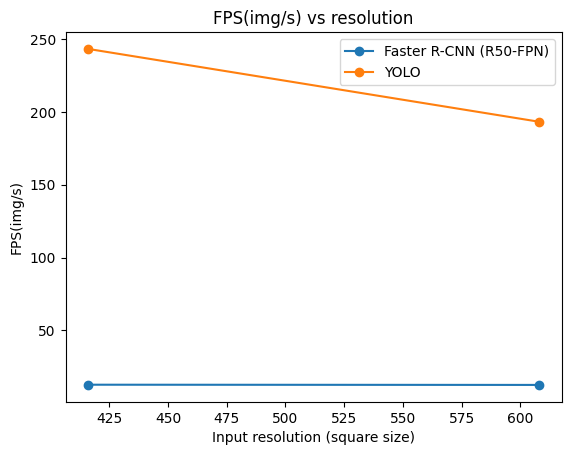

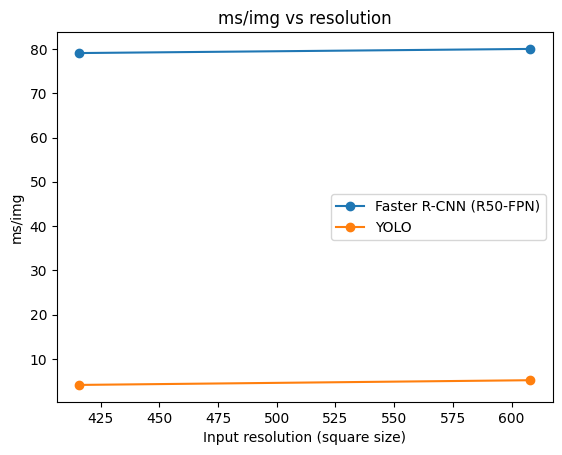

In [9]:
# 시각화

import matplotlib.pyplot as plt

df_plot = df.copy()
df_plot["Size"] = df_plot["Input Size"].str.split("x").str[0].astype(int)

for metric in ["FPS(img/s)", "ms/img"]:
    plt.figure()
    for m in df_plot["Model"].unique():
        sub = df_plot[df_plot["Model"] == m].sort_values("Size")
        plt.plot(sub["Size"], sub[metric], marker="o", label=m)
    plt.xlabel("Input resolution (square size)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs resolution")
    plt.legend()
    plt.show()


## 결과 비교

In [10]:
os.makedirs("vis", exist_ok=True)


In [11]:
from PIL import Image, ImageDraw, ImageFont

def draw_boxes_pil(
    img: Image.Image,
    boxes,        # Tensor or list로 표시
    scores=None,
    labels=None,
    score_thr=0.5
):
    draw = ImageDraw.Draw(img)

    for i, box in enumerate(boxes):
        if scores is not None and scores[i] < score_thr:
            continue

        x1, y1, x2, y2 = map(int, box) # ← 좌표 처리

        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline= 'red',   # 색 지정
            width= 3       # 선 두께
        )

        if labels is not None:
            text = f"{labels[i]} {scores[i]:.2f}"
        else:
            text = str(labels[i])      # label + score
            draw.text(
                (x1, y1),
                text,
                fill= 'red' # 색
            )

    return img

In [12]:
@torch.no_grad()
def run_frcnn_and_draw(model, pil_img, size=416):
    img_rs = resize_pil(pil_img, size)
    x = F.to_tensor(img_rs).to(device)

    pred = model([x])[0]
    boxes  = pred["boxes"].cpu().numpy()
    scores = pred["scores"].cpu().numpy()
    labels = pred["labels"].cpu().numpy()

    label_names = [
        torchvision.models.detection
        .FasterRCNN_ResNet50_FPN_Weights
        .DEFAULT.meta["categories"][l]
        for l in labels
    ]

    vis = draw_boxes_pil(
        img_rs,
        boxes,
        scores=scores,
        labels=label_names,
        score_thr=0.5
    )
    return vis


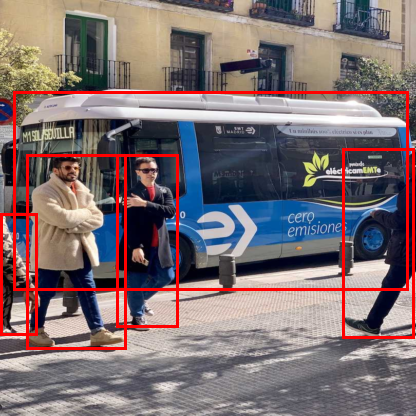

In [13]:
#아래 결과가 나오면 됩니다!!

run_frcnn_and_draw(frcnn, pil_imgs[0], size=416)

# 문제문제

### Q1.
위에서 나온 결과표를 바탕으로, Faster R-CNN과 YOLO 속도 차이를 요약해보세요. 이때 해상도가 증가할수록 두 모델의 속도가 어떻게 변하는지도 설명해주세요.

Ans. ' YOLO는 Faster R-CNN에 비해 전반적으로 매우 빠른 처리 속도를 보임. 입력 해상도가 416×416일 때 YOLO는 약 243 FPS(약 4.11 ms/img)로 동작함. 반면에, Faster R-CNN은 약 12.65 FPS(약 79.08 ms/img)에 그쳐 YOLO가 약 15~20배 이상 빠른 속도를 나타냄. 해상도를 608×608으로 증가시켜도 똑같은 경향임. YOLO는 약 193 FPS(약 5.17 ms/img), Faster R-CNN은 약 12.50 FPS(약 80.01 ms/img)로 큰 변화가 없음.

해상도가 증가할수록 두 모델 모두 연산량 증가로 인해 속도가 감소하는 경향을 보이지만 YOLO는 FPS가 비교적 크게 감소하는 대신에도 여전히 실시간 처리에 충분한 속도를 유지함. 반면 Faster R-CNN은 해상도 증가에 따른 속도 변화가 크지 않지만 기본적으로 처리 시간이 길어 실시간 적용에는 부적합함.'

### Q2.
결과를 확인해보면 Faster R-CNN과 YOLO는 해상도 변화에 따라 받아들이는 정도가 다릅니다. 그 이유에 대해 모델 구조/전처리 관점에서 2가지 가설을 세워보세요.

Ans. 가설 1)  모델 구조 차이로 인한 연산 복잡도의 차이이다. YOLO는 입력 이미지를 한 번의 forward pass로 처리하는 단일 단계 검출기이므로 feature extraction과 bounding box 예측을 동시에 수행함. 이 때문에 입력 해상도가 증가하면 feature map 크기가 커지면서 연산량이 비교적 직접적으로 증가하여 FPS 감소가 명확하게 나타남. 반면에 Faster R-CNN은 두 단계 구조를 가짐. RPN을 통해 후보 영역을 생성한 뒤 RoI 단위로 분류와 회귀를 수행함. 이 과정에서 전체 이미지 해상도보다는 제안된 RoI 개수와 RoI pooling/align 결과에 더 큰 영향을 받기 때문에 입력 해상도가 증가하더라도 전체 처리 속도 변화가 상대적으로 작게 나타날 수 있음.

가설2) 입력 전처리 및 특징 추출 방식의 차이. YOLO는 입력 이미지를 고정된 크기로 리사이즈하여 사용하며 해상도가 커질수록 backbone과 detection head에서 처리해야 하는 feature map의 해상도도 함께 증가함. 이로 인해 convolution 연산량이 크게 늘어나 속도 저하가 발생. 반면에,Faster R-CNN은 FPN 구조를 통해 다중 스케일 feature를 활용하고 RoI Align을 통해 관심 영역만을 고정된 크기의 feature로 변환하여 처리함. 이러한 전처리 및 특징 추출 방식 덕분에 전체 이미지 해상도가 증가하더라도 실제 분류,회귀 단계에서 처리되는 feature 크기는 비교적 일정하게 유지되어서 해상도 변화에 덜 민감하게 반응했을 가능성이 있음.